In [6]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_moons
from sklearn.svm import SVC
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt


In [2]:
# generating non-linear moons dataset
X, y = make_moons(n_samples=150, noise=0.15, random_state=42)


In [3]:
# Defining the visualization engine
def plot_svm_decision_boundary(model, X, y, ax, title):
  """
  Plots the decision highway, margins, and support vectors for an SVM.
  """

  # scatter the raw data
  cmap_light = ListedColormap(['#FFAAAA', '#AAAAFF'])
  cmap_bold = ['darkred', 'darkblue']

  # Create evaluation meshgrid
  x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
  y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
  xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max))

  # Evaluate decision functions accross the entire grid
  Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()])
  Z = Z.reshape(xx.shape)

  # Plot colored background contours
  ax.contourf(xx, yy, Z, levels=[-100, 0, 100], alpha=0.2, colors=['red', 'blue'])

  # Plot decison boundary and margins
  ax.contour(xx, yy, Z, colors='k', levels=[-1, 0, 1], alpha=0.5, linestyles=['--', '-', '--'], linewidths=[1.5, 2.5, 1.5])

  # scatter original data
  ax.scatter(X[:, 0], X[:, 1], c=y, cmap=ListedColormap(cmap_bold), edgecolors='k', s=30, alpha=0.8)

  # Highlight support vectors with large yellow halos
  sv = model.support_vectors_
  ax.scatter(sv[:, 0], sv[:, 1], s=120, facecolors='none', edgecolors='yellow', linewidths=1.5)

  ax.set_title(title, fontsize=12, fontweight='bold')
  ax.set_xticks(())
  ax.set_yticks(())

In [4]:
# Configure the SVM experiments

# Ex 1: Hard Margin (Linear) -> Massive C forces strict boundary (Overfits noise, fails shape)
svm_hard_linear = SVC(kernel='linear', C=1000.0)

# Ex 2: Soft Margin (Linear) -> Low C allows massive slack (Underfits shape, ignores noise)
svm_soft_linear = SVC(kernel='linear', C=0.01)

# Ex 3: RBF Kernel -> Maps non-linear space naturally (Perfect fit)
# Gamma controls the 'spread' of the kernel influence
svm_rbf_kernel = SVC(kernel='rbf', C=10.0, gamma=1.0)

# Train all models
models = [svm_hard_linear, svm_soft_linear, svm_rbf_kernel]
titles = [
    "Exp 1: Hard-Margin Linear (C=1000)\nRigid, Choked by Noise",
    "Exp 2: Soft-Margin Linear (C=0.01)\nWide Highway, Fails Curvature",
    "Exp 3: RBF Kernel SVM\nMaps Organic Non-Linear Shape"
]

for model in models:
  model.fit(X, y)


Exp 1: Hard-Margin Linear (C=1000): Used 50 Support Vectors
Exp 2: Soft-Margin Linear (C=0.01): Used 140 Support Vectors
Exp 3: RBF Kernel SVM: Used 17 Support Vectors


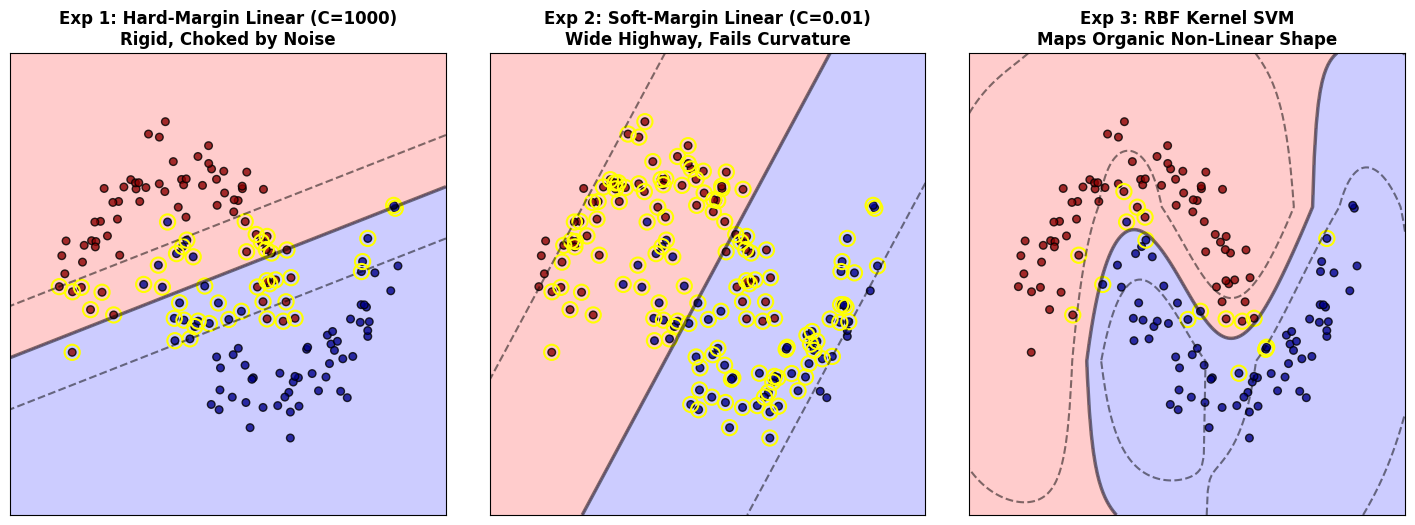

In [7]:
# STEP 4: RENDER THE COMPARISON DASHBOARD
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
plt.subplots_adjust(wspace=0.1)

for idx, ax in enumerate(axes):
    plot_svm_decision_boundary(models[idx], X, y, ax, titles[idx])

    # Print diagnostic stats below the graphs
    support_vector_count = len(models[idx].support_vectors_)
    print(f"{titles[idx].splitlines()[0]}: Used {support_vector_count} Support Vectors")

plt.show()